Cargar dataset

In [1]:
import keras
from tensorflow.keras.preprocessing.image import (
    DirectoryIterator, ImageDataGenerator
)

import os
# Obtener los nombres de los subdirectorios de dataset/train
all_classes = [ d for d in os.listdir('dataset/train') if os.path.isdir(os.path.join('dataset/train', d)) ]

# Solo usamos estas clases por ahora
used_classes = ['bird', 'monkey', 'boar', 'tiger', 'rat', 'ram', 'dog', 'horse', 'hare', 'ox', 'dragon', 'snake']

assert all(c in all_classes for c in used_classes), "Some used classes are not present in the dataset/train directory."

IMAGE_SIZE = 300

BATCH_SIZE = 16

gen = ImageDataGenerator(
    validation_split=0.2,
    horizontal_flip=True,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    fill_mode='nearest'
)

train_dataset = gen.flow_from_directory(
    'dataset/train',
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    classes=used_classes,
    class_mode='categorical',
    subset='training',
)

validation_dataset = gen.flow_from_directory(
    'dataset/train',
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    classes=used_classes,
    class_mode='categorical',
    subset='validation',
)

2025-07-21 21:04:11.463290: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-21 21:04:11.463963: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-21 21:04:11.468413: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-21 21:04:11.481045: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753142651.502792   31877 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753142651.50

Found 1573 images belonging to 12 classes.
Found 387 images belonging to 12 classes.


In [ ]:
# Inception necesita que los pixeles esten entre -1 y 1, esto se consigue con la reescale layer
scale_layer = keras.layers.Rescaling(1./127.5, offset=-1)

# Modelo base de inception v3
base_model = keras.applications.InceptionV3(
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

# NO entrenamos la base
base_model.trainable = False

inputs = keras.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))

model = keras.Sequential([
    inputs,
    scale_layer,
    base_model,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(len(used_classes), activation='softmax') # esta capa clasifica las clases
])

model.summary(
    show_trainable=True
)

2025-07-21 21:04:14.046787: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ rescaling (Rescaling)       │ (None, 300, 300, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ inception_v3 (Functional)   │ (None, 8, 8, 2048)    │ 21,802,784 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d    │ (None, 2048)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense (Dense)               │ (None, 12)            │     24,588 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 21,827,372 (83.26 MB)

 Trainable params: 24,588 (96.05 KB)

 Non-trainable params: 21,802,784 (83.17 MB)

Entrenamos

In [3]:
epochs = 25

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.CategoricalFocalCrossentropy(),#'categorical_crossentropy',
    metrics=['accuracy']
)

# Metemos callbacks
checkpoint_cb = keras.callbacks.ModelCheckpoint(
    'inception_model.weights.h5',
    save_best_only=True,
    save_weights_only=True,
    monitor='val_accuracy',
    mode='max'
)
early_stopping_cb = keras.callbacks.EarlyStopping(
    patience=15,
    monitor='val_accuracy',
    mode='max',
    restore_best_weights=True
)
reduce_lr_cb = keras.callbacks.ReduceLROnPlateau(
    factor=0.1,
    patience=5,
    monitor='val_accuracy',
    mode='max',
    min_lr=1e-7
)

# Entrenamos el modelo
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=epochs,
    callbacks=[checkpoint_cb, early_stopping_cb, reduce_lr_cb]
)

/home/don-berge/Documentos/IIA-TPS/TP-FINAL/.venv/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3681 - loss: 0.4174

/home/don-berge/Documentos/IIA-TPS/TP-FINAL/.venv/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


99/99 ━━━━━━━━━━━━━━━━━━━━ 159s 2s/step - accuracy: 0.3703 - loss: 0.4159 - val_accuracy: 0.7829 - val_loss: 0.1314 - learning_rate: 0.0010
Epoch 2/25
99/99 ━━━━━━━━━━━━━━━━━━━━ 161s 2s/step - accuracy: 0.8062 - loss: 0.1097 - val_accuracy: 0.7778 - val_loss: 0.1013 - learning_rate: 0.0010
Epoch 3/25
99/99 ━━━━━━━━━━━━━━━━━━━━ 161s 2s/step - accuracy: 0.8828 - loss: 0.0675 - val_accuracy: 0.8114 - val_loss: 0.0992 - learning_rate: 0.0010
Epoch 4/25
99/99 ━━━━━━━━━━━━━━━━━━━━ 163s 2s/step - accuracy: 0.8879 - loss: 0.0582 - val_accuracy: 0.8734 - val_loss: 0.0715 - learning_rate: 0.0010
Epoch 5/25
99/99 ━━━━━━━━━━━━━━━━━━━━ 161s 2s/step - accuracy: 0.9109 - loss: 0.0419 - val_accuracy: 0.8010 - val_loss: 0.0733 - learning_rate: 0.0010
Epoch 6/25
99/99 ━━━━━━━━━━━━━━━━━━━━ 162s 2s/step - accuracy: 0.9320 - loss: 0.0375 - val_accuracy: 0.8036 - val_loss: 0.0872 - learning_rate: 0.0010
Epoch 7/25
99/99 ━━━━━━━━━━━━━━━━━━━━ 162s 2s/step - accuracy: 0.9470 - loss: 0.0300 - val_accuracy: 0.88

Graficamos las curvas de entrenamiento

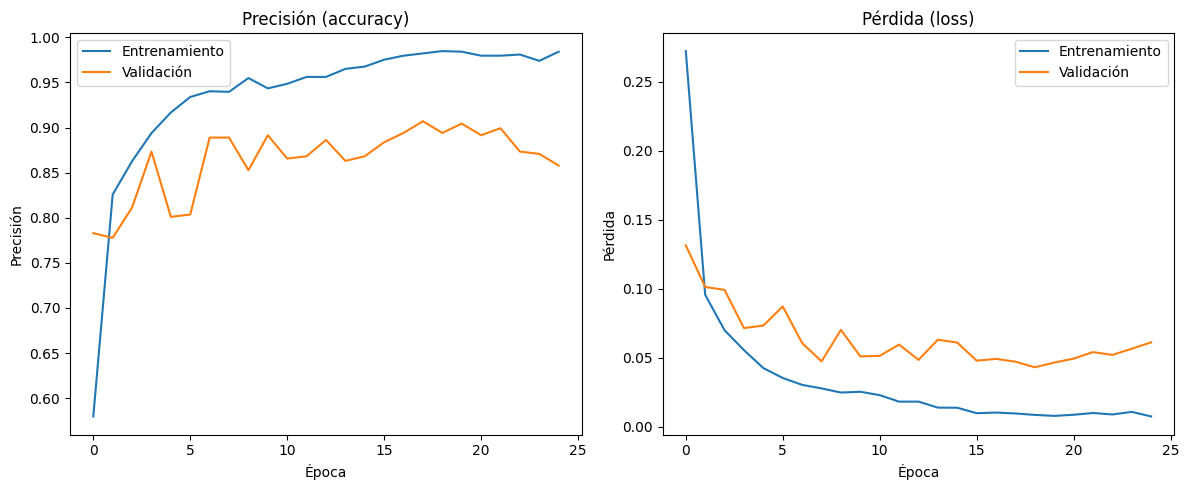

In [4]:
import matplotlib.pyplot as plt

# Graficar accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión (accuracy)')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()

# Graficar loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida (loss)')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()

plt.tight_layout()
plt.show()

Evaluamos sobre el conjunto de train, validacion y test

Found 81 images belonging to 12 classes.


99/99 ━━━━━━━━━━━━━━━━━━━━ 123s 1s/step - accuracy: 0.9726 - loss: 0.0110
25/25 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.8714 - loss: 0.0549
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.6127 - loss: 0.2119


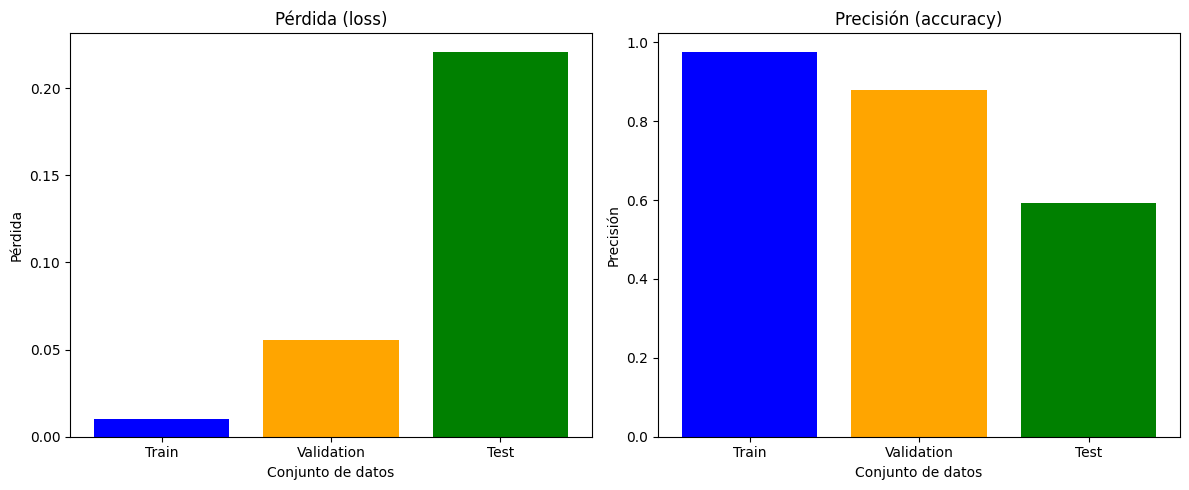

In [5]:
test_dataset = ImageDataGenerator()

test_dataset = test_dataset.flow_from_directory(
    'dataset/test',
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=32,
    classes=used_classes,
    class_mode='categorical',
)

# Evaluamos el modelo
train_loss, train_accuracy = model.evaluate(train_dataset)
validation_loss, validation_accuracy = model.evaluate(validation_dataset)
test_loss, test_accuracy = model.evaluate(test_dataset)

# Graficar el loss y accuracy de train, validacion y test
# en un histograma, donde cada columna tiene un color diferente
labels = ['Train', 'Validation', 'Test']
losses = [train_loss, validation_loss, test_loss]
accuracies = [train_accuracy, validation_accuracy, test_accuracy]
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.bar(labels, losses, color=['blue', 'orange', 'green'])
plt.title('Pérdida (loss)')
plt.xlabel('Conjunto de datos')
plt.ylabel('Pérdida')
plt.subplot(1, 2, 2)
plt.bar(labels, accuracies, color=['blue', 'orange', 'green'])
plt.title('Precisión (accuracy)')
plt.xlabel('Conjunto de datos')
plt.ylabel('Precisión')
plt.tight_layout()
plt.show()


Ahora hacemos fine tunning

In [6]:
# Ahora hacemos fine tunning
base_model_layers = len(base_model.layers)

print(f"Base model has {base_model_layers} layers.")

finetunning_layers = 100  # Fine-tune the last 100 layers
fine_tune_at = base_model_layers - finetunning_layers  # Fine-tune the last 100 layers
print("Non trainable layers:", fine_tune_at)
print("Trainable layers:", base_model_layers - fine_tune_at)

# Descongelamos las capas que vamos a entrenar
for layer in base_model.layers[fine_tune_at:]:
    layer.trainable = True

# Recompilamos el modelo con un learning rate más bajo
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss=keras.losses.CategoricalFocalCrossentropy(),
    metrics=['accuracy']
)

finetunning_epochs = 10
total_epochs = len(history.epoch) + finetunning_epochs

# Entrenamos el modelo de nuevo
history_fine_tune = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=total_epochs,
    callbacks=[checkpoint_cb, early_stopping_cb, reduce_lr_cb],
    initial_epoch=len(history.epoch)
)

Base model has 311 layers.
Non trainable layers: 211
Trainable layers: 100
Epoch 26/35
99/99 ━━━━━━━━━━━━━━━━━━━━ 228s 2s/step - accuracy: 0.8636 - loss: 0.0685 - val_accuracy: 0.8424 - val_loss: 0.0777 - learning_rate: 1.0000e-04
Epoch 27/35
99/99 ━━━━━━━━━━━━━━━━━━━━ 208s 2s/step - accuracy: 0.9780 - loss: 0.0059 - val_accuracy: 0.8811 - val_loss: 0.0615 - learning_rate: 1.0000e-04
Epoch 28/35
99/99 ━━━━━━━━━━━━━━━━━━━━ 211s 2s/step - accuracy: 0.9778 - loss: 0.0084 - val_accuracy: 0.9121 - val_loss: 0.0435 - learning_rate: 1.0000e-04
Epoch 29/35
99/99 ━━━━━━━━━━━━━━━━━━━━ 210s 2s/step - accuracy: 0.9924 - loss: 0.0031 - val_accuracy: 0.9199 - val_loss: 0.0414 - learning_rate: 1.0000e-04
Epoch 30/35
99/99 ━━━━━━━━━━━━━━━━━━━━ 209s 2s/step - accuracy: 0.9873 - loss: 0.0032 - val_accuracy: 0.8837 - val_loss: 0.0490 - learning_rate: 1.0000e-04
Epoch 31/35
99/99 ━━━━━━━━━━━━━━━━━━━━ 209s 2s/step - accuracy: 0.9874 - loss: 0.0044 - val_accuracy: 0.9432 - val_loss: 0.0259 - learning_rate: 

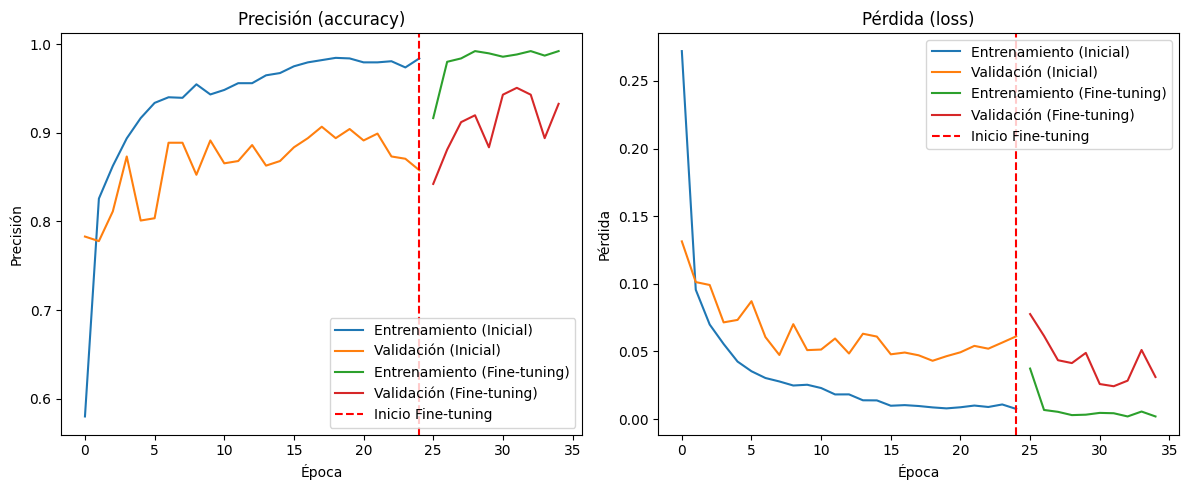

In [7]:
# Graficar curvas del fine tunning junto con las anteriores
# Graficar accuracy y loss de ambas fases, marcando el inicio del fine-tuning
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
# Fase inicial
plt.plot(history.history['accuracy'], label='Entrenamiento (Inicial)')
plt.plot(history.history['val_accuracy'], label='Validación (Inicial)')
# Fine-tuning
epochs_finetune = range(len(history.history['accuracy']), len(history.history['accuracy']) + len(history_fine_tune.history['accuracy']))
plt.plot(epochs_finetune, history_fine_tune.history['accuracy'], label='Entrenamiento (Fine-tuning)')
plt.plot(epochs_finetune, history_fine_tune.history['val_accuracy'], label='Validación (Fine-tuning)')
# Línea divisoria
plt.axvline(x=len(history.history['accuracy'])-1, color='red', linestyle='--', label='Inicio Fine-tuning')
plt.title('Precisión (accuracy)')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento (Inicial)')
plt.plot(history.history['val_loss'], label='Validación (Inicial)')
plt.plot(epochs_finetune, history_fine_tune.history['loss'], label='Entrenamiento (Fine-tuning)')
plt.plot(epochs_finetune, history_fine_tune.history['val_loss'], label='Validación (Fine-tuning)')
plt.axvline(x=len(history.history['loss'])-1, color='red', linestyle='--', label='Inicio Fine-tuning')
plt.title('Pérdida (loss)')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()

plt.tight_layout()
plt.show()

Found 81 images belonging to 12 classes.
99/99 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - accuracy: 0.9950 - loss: 0.0024
25/25 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.9384 - loss: 0.0270
9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 962ms/step - accuracy: 0.7723 - loss: 0.1233


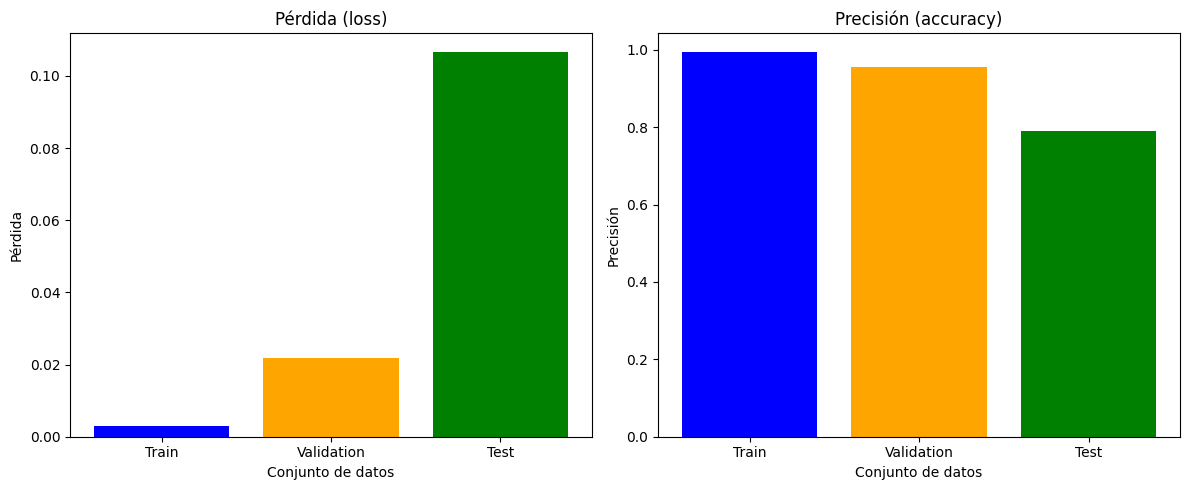

In [8]:
test_dataset = ImageDataGenerator()

test_dataset = test_dataset.flow_from_directory(
    'dataset/test',
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=10,
    classes=used_classes,
    class_mode='categorical',
)

# Evaluamos el modelo
train_loss, train_accuracy = model.evaluate(train_dataset)
validation_loss, validation_accuracy = model.evaluate(validation_dataset)
test_loss, test_accuracy = model.evaluate(test_dataset)

# Graficar el loss y accuracy de train, validacion y test
# en un histograma, donde cada columna tiene un color diferente
labels = ['Train', 'Validation', 'Test']
losses = [train_loss, validation_loss, test_loss]
accuracies = [train_accuracy, validation_accuracy, test_accuracy]
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.bar(labels, losses, color=['blue', 'orange', 'green'])
plt.title('Pérdida (loss)')
plt.xlabel('Conjunto de datos')
plt.ylabel('Pérdida')
plt.subplot(1, 2, 2)
plt.bar(labels, accuracies, color=['blue', 'orange', 'green'])
plt.title('Precisión (accuracy)')
plt.xlabel('Conjunto de datos')
plt.ylabel('Precisión')
plt.tight_layout()
plt.show()


Evaluamos sobre el conjunto de test

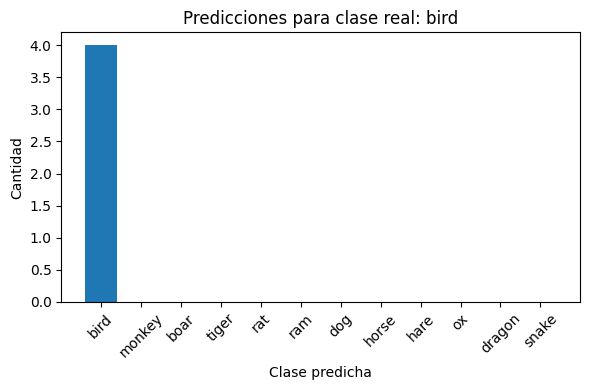

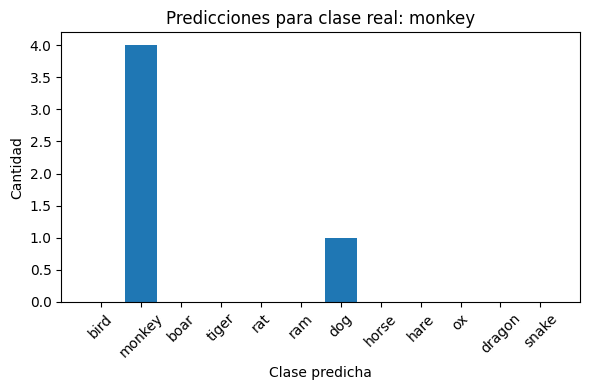

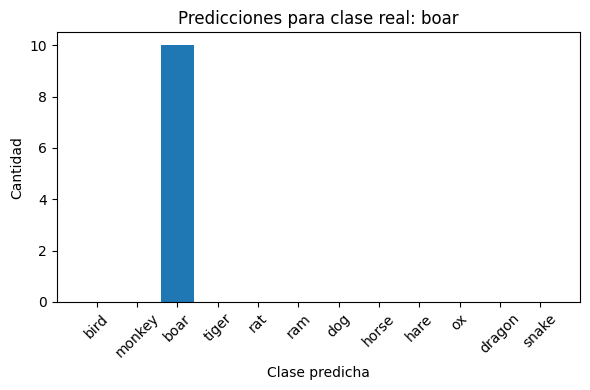

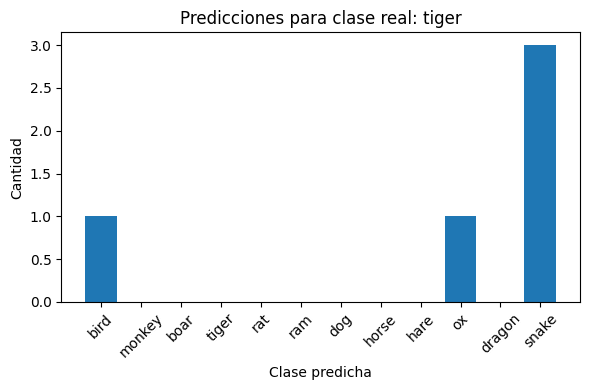

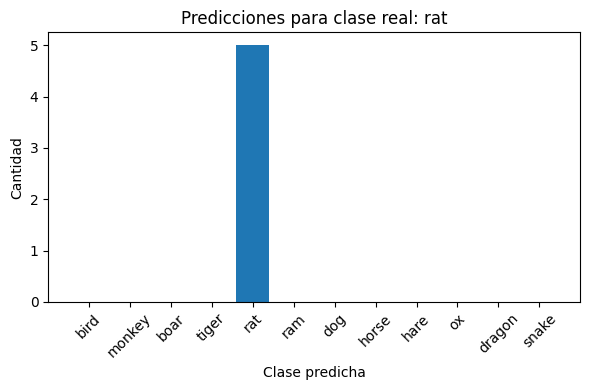

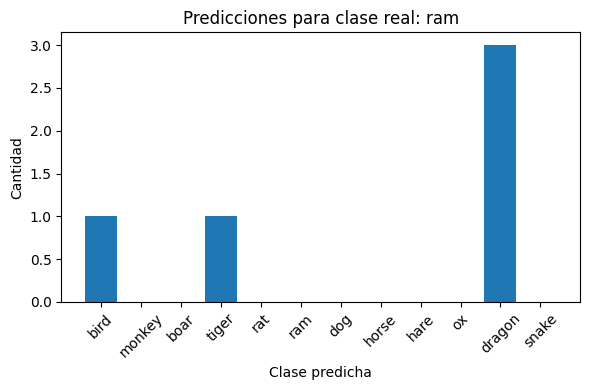

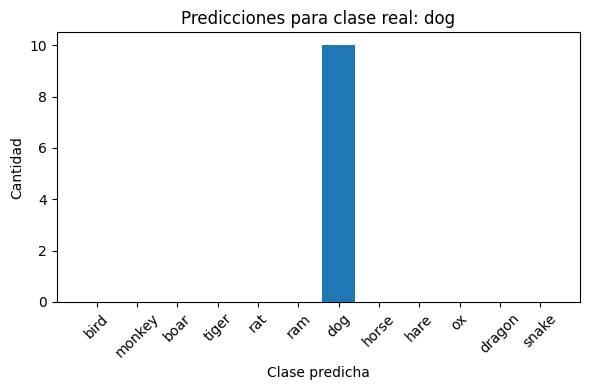

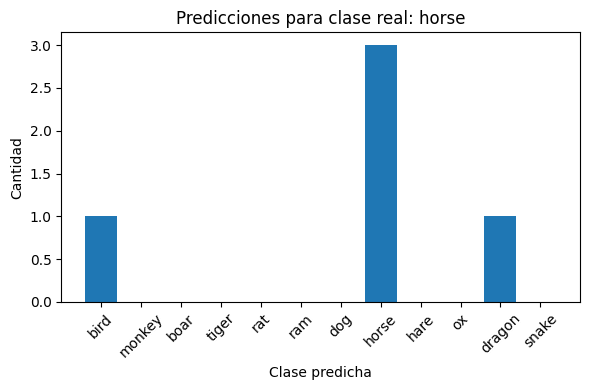

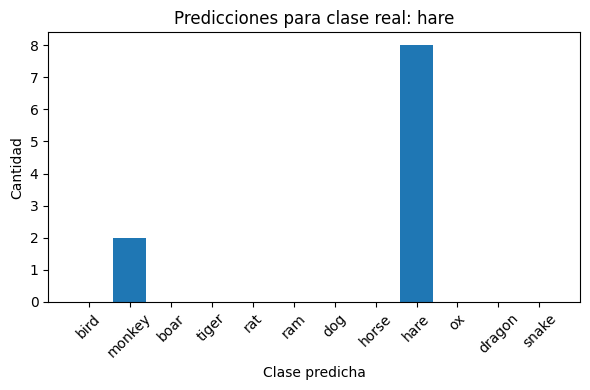

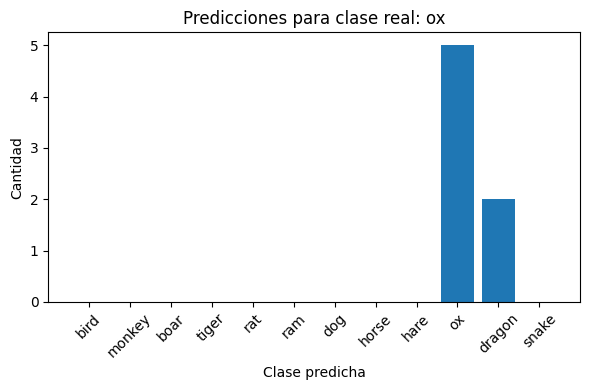

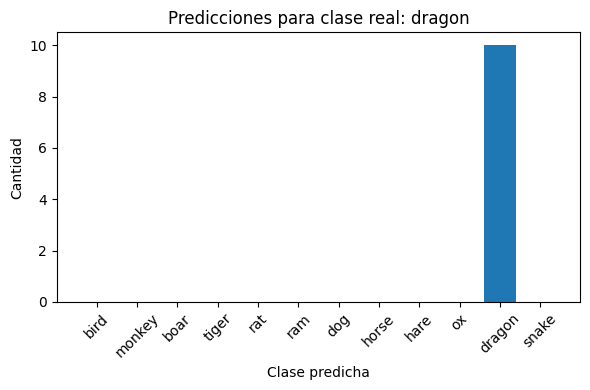

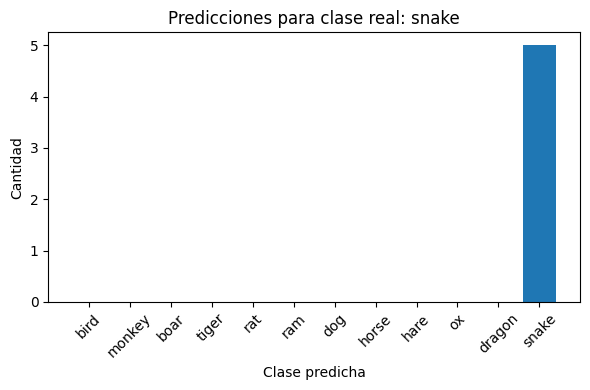

In [9]:
import numpy as np

dataset = test_dataset

# Obtener nombres de clases y número de clases
class_indices = dataset.class_indices
class_names = list(class_indices.keys())
num_classes = len(class_names)

# Obtener todas las imágenes y etiquetas verdaderas del test set
dataset.reset()
y_true = []
y_pred = []

for i in range(len(dataset)):
    x_batch, y_batch = dataset[i]
    preds = model.predict(x_batch, verbose=0)
    y_true.extend(np.argmax(y_batch, axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Graficar un histograma por clase real, cada uno en una figura separada
for idx, class_name in enumerate(class_names):
    mask = y_true == idx
    pred_for_class = y_pred[mask]
    plt.figure(figsize=(6, 4))
    plt.hist(pred_for_class, bins=np.arange(num_classes+1)-0.5, rwidth=0.8, align='mid')
    plt.xticks(range(num_classes), class_names, rotation=45)
    plt.title(f'Predicciones para clase real: {class_name}')
    plt.xlabel('Clase predicha')
    plt.ylabel('Cantidad')
    plt.tight_layout()
    plt.show()


In [10]:
# Guardar el modelo
model.save('naruto_signs_{}.keras'.format(len(used_classes)))